# 6. DOMEK: quantitative enzyme profiling

This notebook demonstrates the use of clibas to analyze mRNA display-based enzyme profiling outcomes with the data from Vinogradov and Suga. Primarily, this example aims to demonstrate i) the use of `C.pipeline.stream` and `C.data_loader.stream_from_gz_file` methods to process large `.fastq` files, and ii) advanced read filtering based on the library design specifications. 

For further details and the source of data, see [A. Vinogradov and H. Suga. Measuring k<sub>cat</sub>/K<sub>M</sub> values for over 200,000 enzymatic substrates with mRNA display. Chem 2026, 12, 102737](https://www.cell.com/chem/abstract/S2451-9294(25)00328-6)

In the paper, the authors prepare an mRNA display library of peptide substrates for a post-translational modification enzyme, and then use it to measure the enzymatic kinetics of each individual substrate in a one-shot experiment from the associated NGS data. The details of this so-called DOMEK workflow are not critical here - refer to the paper for a complete method description. 

The authors released the entire NGS dataset which contains over one billion reads split between 33 `.fastq` files. Released are merged R1/R2 files from paired-end sequencing runs. The reads look something like this:

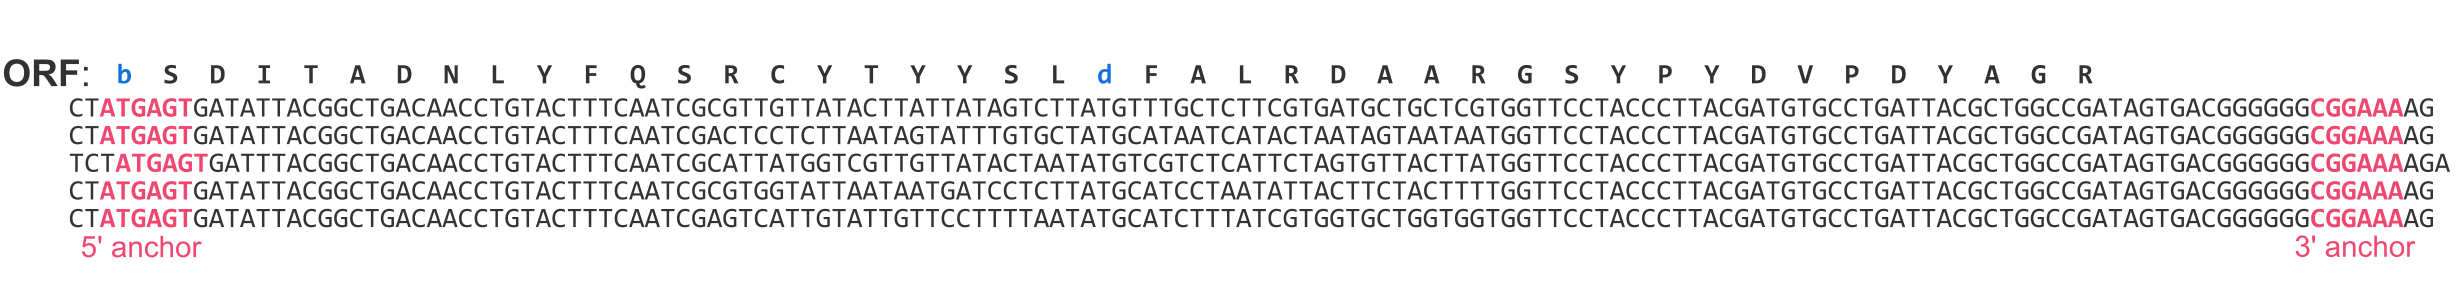

There is some variability in how adapter sequences are trimmed, but either way, the reads capture the entire ORF of interest.

The library is comprised of a single template sequence that encodes an ORF bearing a TEV cleavage site on the N-terminus followed by a 16-amino acid variable region. The variable region encloses an `ATG` codon that encodes a non-stanadard dehydroalanine amino acid which is installed by genetic code reprogramming (here denoted as `d`). Varible amino acids are encoded by `NNT` degenerate codons, and there are 15 possibilities at each position. The HA peptide sequence comprises the second constant region at the C-terminus. Finally, genetic code reprogramming at the translation initiation position results in the non-standard amino acid in position 1 (`b` which stands for for N-biotin-Phe).

The library designs can be written accordingly:

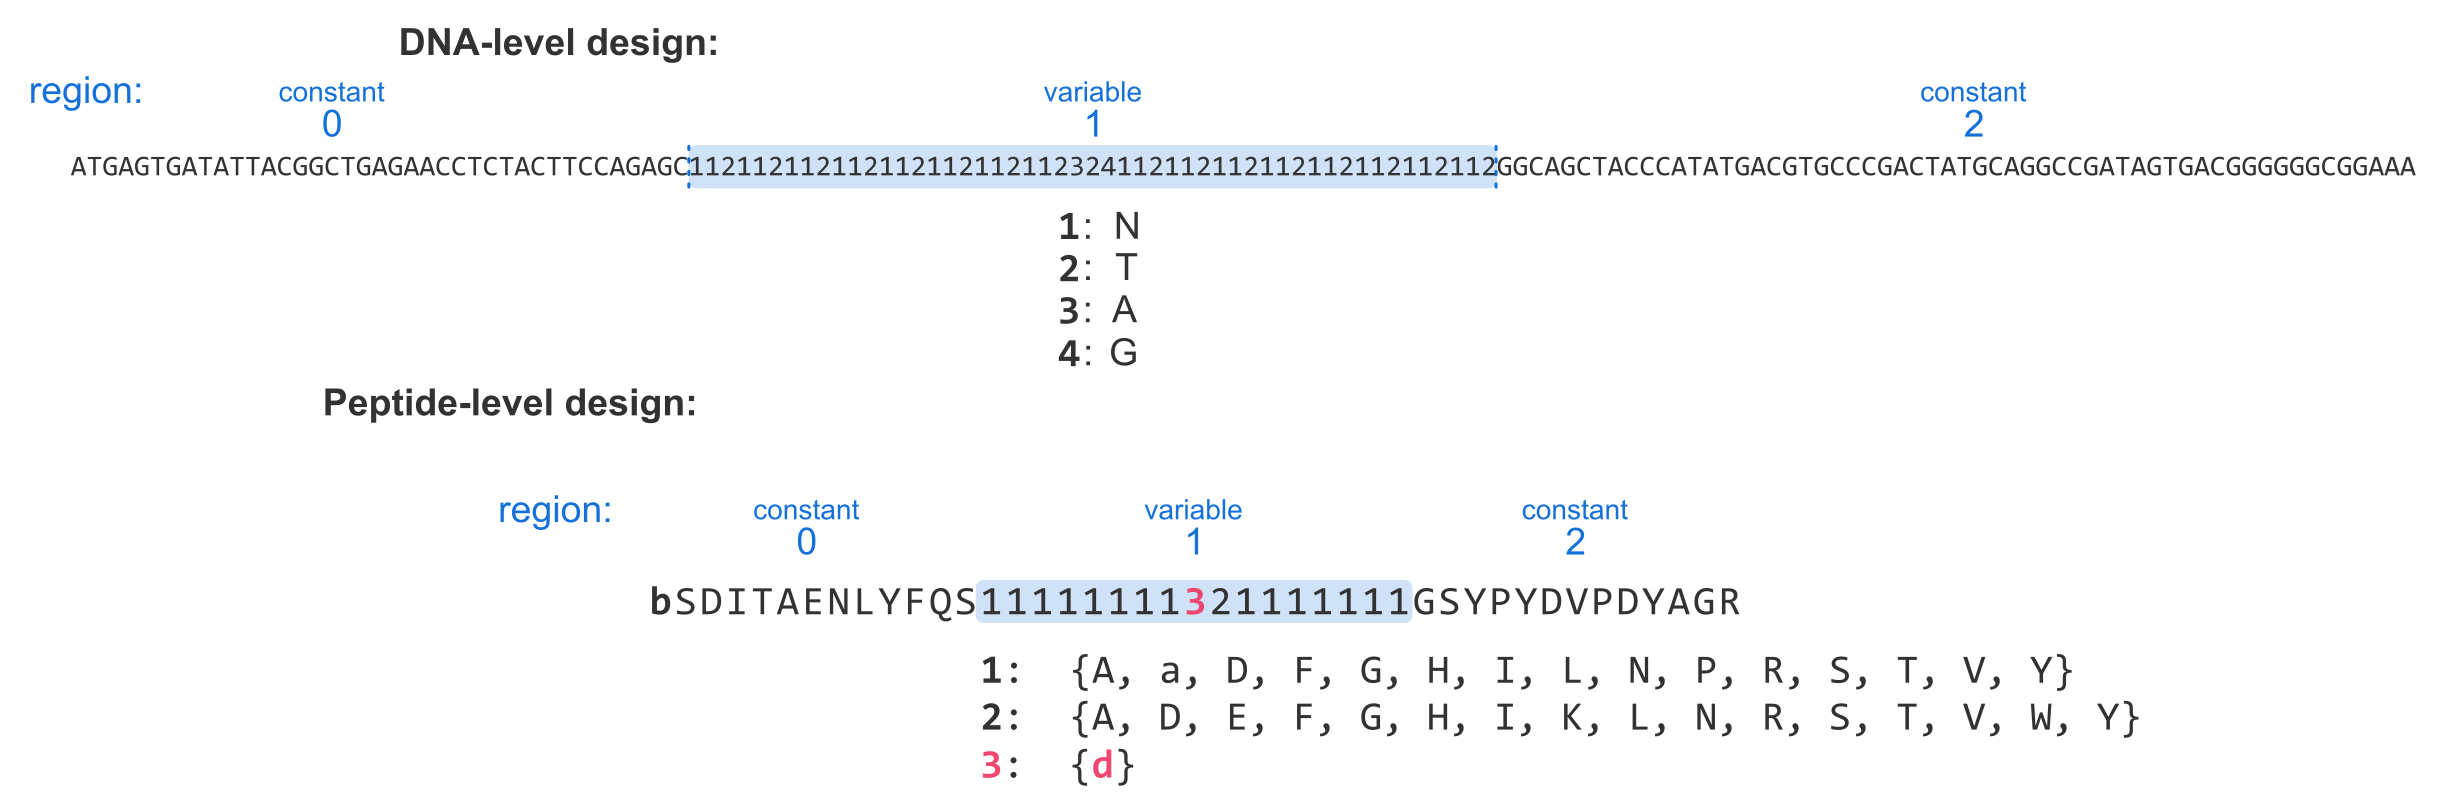

Although the middle `d` is fixed and can be represented as a constant region of size 1, it is convenient to include it in the larger random insert, because it leaves us with fewer regions to keep track of and because the random region of interest can be conveniently captured with `C.fastq_parser.fetch_at(where='pep', loc=[1])` in the pipeline. 

To write a `.yaml` config file for this library, in addition to the library design we also need to specify a custom translation table where the `ATG` elongation codon encodes `d` and cysteine codons (`TGC` and `TGT`) correspond to `a` (N-Me-Ala, another non-standard amino acid installed with the use of genetic code reprogramming). A `custom_ini_aa` specification is needed to account for the non-standard translation initiator amino acid (`b`). We won't run UMAP/HDBSCAN analysis (this isn't affinity selection, and such analysis is not very useful), so there is no need to provide `aa_SMILES` in the config. The final `.yaml` file then looks like this:

```yaml
experiment: "FltJ_DOMEK_pipeline"

constants:
  description: |
    Star symbol (*) is internally reserved for stop codons that terminate
    translation.
    
    Plus and underscore symbols (+ and _) are internally reserved tokens.
    Numerals (1234567890) are internally reserved for library design 
    specifications. These symbols (123456790+_) should not be used to
    encode amino acids.
    
    Other symbols are OK.   
    
  translation_table:
    ATA: "I"
    ATC: "I"
    ATT: "I"
    ATG: "d" #Dha
    ACA: "T"
    ACC: "T"
    ACG: "T"
    ACT: "T"
    AAC: "N"
    AAT: "N"
    AAA: "K"
    AAG: "K"
    AGC: "S"
    AGT: "S"
    AGA: "R"
    AGG: "R"
    CTA: "L"
    CTC: "L"
    CTG: "L"
    CTT: "L"
    CCA: "P"
    CCC: "P"
    CCG: "P"
    CCT: "P"
    CAC: "H"
    CAT: "H"
    CAA: "Q"
    CAG: "Q"
    CGA: "R"
    CGC: "R"
    CGG: "R"
    CGT: "R"
    GTA: "V"
    GTC: "V"
    GTG: "V"
    GTT: "V"
    GCA: "A"
    GCC: "A"
    GCG: "A"
    GCT: "A"
    GAC: "D"
    GAT: "D"
    GAA: "E"
    GAG: "E"
    GGA: "G"
    GGC: "G"
    GGG: "G"
    GGT: "G"
    TCA: "S"
    TCC: "S"
    TCG: "S"
    TCT: "S"
    TTC: "F"
    TTT: "F"
    TTA: "L"
    TTG: "L"
    TAC: "Y"
    TAT: "Y"
    TAA: "*"
    TAG: "*"
    TGC: "a" #N-Me-Ala
    TGT: "a" #N-Me-Ala
    TGA: "*"
    TGG: "W"

  custom_ini_aa: "b" #N-biotin-Phe 

LibraryDesigns:
  dna_templates:
    - "ATGAGTGATATTACGGCTGAGAACCTCTACTTCCAGAGC112112112112112112112112324112112112112112112112112GGCAGCTACCCATATGACGTGCCCGACTATGCAGGCCGATAGTGACGGGGGGCGGAAA"
    
  dna_monomers:
    1: ["A", "G", "T", "C"]
    2: ["T"]
    3: ["A"]
    4: ["G"]
    
  pep_templates:
    - "bSDITAENLYFQS11111111321111111GSYPYDVPDYAGR"
    
  pep_monomers:
    1: ["A", "a", "D", "F", "G", "H", "I", "L", "N", "P", "R", "S", "T", "V", "Y"]
    2: ["A", "D", "E", "F", "G", "H", "I", "K", "L", "N", "R", "S", "T", "V", "W", "Y"]
    3: ["d"]

TrackerConfig:
  logs: "./outputs/Vinogradov_DOMEK"                 # Directory for writing logs to
  parser_out: "./outputs/Vinogradov_DOMEK"           # Directory that stores fastq parser outputs
  analysis_out: "./outputs/Vinogradov_DOMEK"         # Directory that stores outputs of data analysis operations

LoggerConfig:
  verbose: true                     # Verbose loggers print to the console
  log_to_file: true                 # Write logs to file
  level: "INFO"                     # Logger level; accepted values: "DEBUG", "INFO", "WARNING", "ERROR"
```

For this example, we will analyze just the naive library sample (uploaded by the authors as `r_rec_8m8_v2_m.gz`). It contains nearly 88M reads and will not fit the memory on my machine (64 Gb RAM). We will need to "stream" reads from the file. The way clibas accomplishes this is by loading the file in chunks, `reads_per_chunk` number of reads at a time. Every chunk then gets processed as its own sample in sequence until the file is depleted. This creates its own set of outputs for each chunk, but they can be merged later. In the future, we plan on developing the code to aggregate outputs across chunks by default. 

Here, we will load 20M reads at a time. This will create 5 outputs that we will merge downstream.

To build a pipeline, we will trim reads first to make sure that we can kickstart translation with `force_at_frame=0` in the following operation. 

We will then discard peptides which:
1. don't match the library sequence length, 
2. accumulate more than 5 mutations across the constant regions, 
3. contain disallowed amino acids in sets 1 and 2 in the variable region, 
4. lack the central dehydroalanine `d` in the variable region, 
5. have any Q scores below 23 in region 1 (correspond to the variable region; Q scores in the constant regions are not checked),
6. have any "ambiguous" amino acids in the sequence; these are usually denoted as `_` by clibas and can arise when attempting translation from degenerate codons (e.g., `NGT`); degenerate codons in turn are sometimes encountered because some sequencers allow `N` base calls.

Then, finally, we will clip the sequences to region 1 (varible region), and save the data. DOMEK's downstream pipeline requires NumPy's `.npy` files, so will just save those. 

Note that operations 3 and 4 can be merged in one as `C.fastq_parser.vr_filter(where='pep', loc=[1], sets=[1, 2, 3])`. We split it in two to see how many peptides each filtering step removes. This can be helpful when debugging. 

In [1]:
import clibas as C
C.initialize('Vinogradov_DOMEK_config.yaml')

C.pipeline.enque([
                  C.fastq_parser.trim_reads(left='ATGAGT', right='CGGAAA', tol=1),
                  C.fastq_parser.translate(force_at_frame=0, stop_readthrough=False),
                  C.fastq_parser.len_filter(where='pep'),
                  C.fastq_parser.cr_filter(where='pep', loc=[0, 2], tol=5),
                  C.fastq_parser.vr_filter(where='pep', loc=[1], sets=[1, 2]),
                  C.fastq_parser.vr_filter(where='pep', loc=[1], sets=[3]),
                  C.fastq_parser.q_score_filt(minQ=23, loc=[1]),
                  C.fastq_parser.fetch_at(where='pep', loc=[1]),
                  C.fastq_parser.filt_ambiguous(where='pep'),
                  C.fastq_parser.save(where='pep', fmt='npy')
]
)

streamer = C.data_loader.stream_from_gz_file(fname='./sequencing_data/Vinogradov_FltJ_DOMEK/r_rec_8m8_v2_m.gz', 
                                             reads_per_chunk=int(2e7)
)

C.pipeline.stream(streamer, save_summary=True)

[INFO]: <clibas> succesfully loaded config and is ready. . .
[INFO]: 10 ops appended to pipeline; current queue size: 10
[INFO]: Streaming from r_rec_8m8_v2_m.gz file. . .
[INFO]: Fetching r_rec_8m8_v2_m_001. . .
[INFO]: r_rec_8m8_v2_m_001 dataset size: 20000000
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <trim_exp> op. . .
[INFO]: The operation took 42.017 s
[INFO]: r_rec_8m8_v2_m_001 dataset size: 20000000
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <translate_dna> op. . .
[INFO]: The operation took 195.678 s
[INFO]: r_rec_8m8_v2_m_001 dataset size: 20000000
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <length_filter> op. . .
[INFO]: The operation took 20.479 s
[INFO]: r_rec_8m8_v2_m_001 dataset size: 16995185
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <constant_region_filter> op. . .
[INFO]: The operat

In all, 88M reads were processed in 30.6 min.

The logs above indicate that some operations discarded very few reads (e.g., <0.1% of all reads at the time of filtering did not have a `d` amino acid in the middle of the variable region). Nonetheless, these subtle denoising steps help ensure the accuracy of the resulting DOMEK workflows. 

The output `.npy` files containing final peptide lists for each chunk can now be loaded and concatenated for downstream DOMEK applications:

In [16]:
import os
import numpy as np

source = list(os.walk('./outputs/Vinogradov_DOMEK'))

peptides = []
for i in source:
    for file in i[2]:
        if file.endswith('.npy'):
            arr = np.load(os.path.join(i[0], file))
            peptides.append(arr)

peptides = np.concatenate(peptides)
print(f'The final peptide dataset size: {peptides.size:.3e} sequences')

The final peptide dataset size: 6.970e+07 sequences


To save space, clibas stores all numpy data as byte arrays; they can be converted into regular string arrays if needed. This will take some time for large arrays like this one:

In [10]:
peptides[:10]

array([b'SPHGNLHTdAHVPHAYY', b'SNaPHNAHdAHSNSAYI', b'LAHPGTYHdWNLFGIGT',
       b'DHIRRaSNdKVNGIITL', b'DVARSGHHdANSNSLGY', b'NDSSDRRHdKHRGHGAS',
       b'RSaNFLDVdARGDDRNN', b'GaTYTYDTdEHSPDSAH', b'GaSFNaSDdDDTGSSRD',
       b'RHSPAHIadSPYPGTRP'], dtype='|S17')

In [15]:
peptides.view('S1').reshape((peptides.size, -1)).astype('U1')

array([['S', 'P', 'H', ..., 'A', 'Y', 'Y'],
       ['S', 'N', 'a', ..., 'A', 'Y', 'I'],
       ['L', 'A', 'H', ..., 'I', 'G', 'T'],
       ...,
       ['V', 'a', 'A', ..., 'R', 'G', 'T'],
       ['P', 'L', 'S', ..., 'R', 'N', 'T'],
       ['A', 'a', 'I', ..., 'A', 'P', 'F']],
      shape=(69695977, 17), dtype='<U1')

This concludes example 6.